# SMS Spam Classification using NLP

# *Step 1 - Reading Data and Visualization*

Import Modules

In [2]:
import pandas as pd
import nltk

Read dataset

In [3]:
df = pd.read_csv("spam.csv", encoding = "latin - 1")

FileNotFoundError: [Errno 2] No such file or directory: 'spam.csv'

In [6]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [9]:
df.rename(columns={'v1':'class','v2':'sms'},inplace = True)
df.sample(5)

,class,sms
255,ham,Don't necessarily expect it to be done before ...
495,ham,Got meh... When?
1408,ham,"I've got ten bucks, jay is being noncomittal"
196,ham,Did u got that persons story
1555,ham,Ok i found dis pierre cardin one which looks n...


In [10]:
df.groupby('class').describe()

sms                                                               
      count unique                                                top freq
class                                                                     
ham    4825   4516                             Sorry, I'll call later   30
spam    747    653  Please call our customer service representativ...    4

In [11]:
df = df.drop_duplicates(keep = 'first')

In [12]:
df.groupby('class').describe()

sms                                                               
      count unique                                                top freq
class                                                                     
ham    4516   4516                         Rofl. Its true to its name    1
spam    653    653  This is the 2nd time we have tried 2 contact u...    1

# Data Visualization


In [13]:
df["Length"] = df["sms"].apply(len)

In [14]:
df.head(2)

,class,sms,Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29


array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

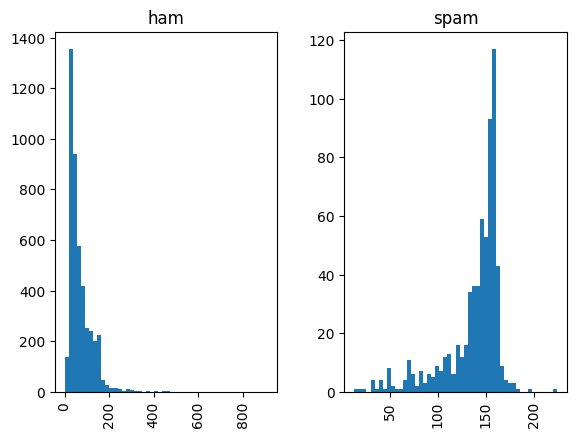

In [15]:
df.hist(column = 'Length', by ='class', bins = 50)

# Step 2 - Preprocessing

In [16]:
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')
from nltk.corpus import stopwords
import nltk
nltk.download('punkt_tab')
ps = PorterStemmer()





[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [17]:
df.head(5)

,class,sms,Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


Preprocessing Tasks :


*  Lower Case
*  Tokenization


*  Removing special characters
* Removing stop words and punctuation


*   Stemming

















In [18]:
import string

def clean_text(text):
  text = str(text).lower()
  text = nltk.word_tokenize(text)

  filtered_tokens_alphanum = []
  for token in text:
    if token.isalnum():
      filtered_tokens_alphanum.append(token)

  filtered_tokens_no_stopwords = []
  for token in filtered_tokens_alphanum:
    if token not in stopwords.words('english') and token not in string.punctuation:
      filtered_tokens_no_stopwords.append(token)

  stemmed_tokens = []
  for token in filtered_tokens_no_stopwords:
    stemmed_tokens.append(ps.stem(token))

  return " ".join(stemmed_tokens)

In [19]:
df['sms_cleaned'] = df['sms'].apply(clean_text)

In [20]:
df.head(5)

,class,sms,Length,sms_cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


# Step 3 - Feature Extraction

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:

df['sms_cleaned'] = df['sms_cleaned'].fillna('')

tf_vec = TfidfVectorizer(max_features = 3000)
x = tf_vec.fit_transform(df['sms_cleaned']).toarray()

In [23]:
x.shape

(5169, 3000)

In [24]:
y = df['class'].values

# Step 4 - Learning

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 2)

In [27]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train , y_train)

MultinomialNB()

MultinomialNB()

In [28]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9709864603481625
